<a href="https://colab.research.google.com/github/mrJay188/AI-ML/blob/main/Full_Pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

In [ ]:
train = pd.read_csv('/content/drive/MyDrive/Datasets/train.csv')
test = pd.read_csv('/content/drive/MyDrive/Datasets/train.csv')

In [ ]:
print("shape of Train Data ",train.shape)
print("shape of Test Data ",test.shape)

shape of Train Data  (1460, 81)
shape of Test Data  (1460, 81)


In [ ]:
train.isnull().sum()

,0
Id,0
MSSubClass,0
MSZoning,0
LotFrontage,259
LotArea,0
...,...
MoSold,0
YrSold,0
SaleType,0
SaleCondition,0


In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [ ]:
train.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [ ]:
train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [ ]:
train['SalePrice']

,SalePrice
0,208500
1,181500
2,223500
3,140000
4,250000
...,...
1455,175000
1456,210000
1457,266500
1458,142125


In [ ]:
x_train = train.drop(columns=['SalePrice'],axis=1)
y_train = train['SalePrice']

In [ ]:
x_test = test.copy()

In [ ]:
print("shape of x_train ",x_train.shape)
print("shape of y_train ",y_train.shape)
print("shape of x_test ",x_test.shape)

shape of x_train  (1460, 80)
shape of y_train  (1460,)
shape of x_test  (1460, 81)


In [ ]:
isnull_sum = x_train.isnull().sum()
isnull_sum

,0
Id,0
MSSubClass,0
MSZoning,0
LotFrontage,259
LotArea,0
...,...
MiscVal,0
MoSold,0
YrSold,0
SaleType,0


Numerical Values

In [ ]:
num_vars = x_train.select_dtypes(include=['int64','float64']).columns
num_vars

Index(['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual',
       'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd',
       'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF',
       'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea',
       'MiscVal', 'MoSold', 'YrSold'],
      dtype='object')

In [ ]:
num_var_miss = [var for var in num_vars if isnull_sum[var]>0]


In [ ]:
num_var_miss

['LotFrontage', 'MasVnrArea', 'GarageYrBlt']

Categorical Values

In [ ]:
cat_vars = x_train.select_dtypes(include=['object']).columns
cat_vars

Index(['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',
       'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual',
       'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature',
       'SaleType', 'SaleCondition'],
      dtype='object')

In [ ]:
cat_vars_miss = [var for var in cat_vars if isnull_sum[var]>0]
cat_vars_miss

['Alley',
 'MasVnrType',
 'BsmtQual',
 'BsmtCond',
 'BsmtExposure',
 'BsmtFinType1',
 'BsmtFinType2',
 'Electrical',
 'FireplaceQu',
 'GarageType',
 'GarageFinish',
 'GarageQual',
 'GarageCond',
 'PoolQC',
 'Fence',
 'MiscFeature']

In [ ]:
num_vars_mean = ['LotFrontage']
num_vars_median = ['MasVnrArea', 'GarageYrBlt']
cat_vars_mode = ['Alley',
 'MasVnrType',
 'BsmtQual',
 'BsmtCond',
 'BsmtExposure',
 'BsmtFinType1',
 'BsmtFinType2',
 'Electrical',
 'FireplaceQu']

 # constant value
cat_vars_constant_missing = ['GarageType',
 'GarageFinish',
 'GarageQual',
 'GarageCond',
 'PoolQC',
 'Fence',
 'MiscFeature']

In [ ]:
num_vars_mean_imputer = Pipeline(steps = [('imputer', SimpleImputer(strategy = 'mean'))])
num_vars_median_imputer = Pipeline(steps = [('imputer', SimpleImputer(strategy = 'median'))])
cat_vars_mode_imputer = Pipeline(steps = [('imputer', SimpleImputer(strategy = 'most_frequent'))])
cat_vars_constatnt_imputer = Pipeline(steps = [('imputer', SimpleImputer(strategy = 'constant', fill_value = 'missing'))])

In [ ]:
num_vars_mean_imputer

Pipeline(steps=[('imputer', SimpleImputer())])

In [ ]:
num_vars_median_imputer

Pipeline(steps=[('imputer', SimpleImputer(strategy='median'))])

In [ ]:
cat_vars_mode_imputer

Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent'))])

In [ ]:
cat_vars_constatnt_imputer

Pipeline(steps=[('imputer',
                 SimpleImputer(fill_value='missing', strategy='constant'))])

# ColumnTransformer

In [ ]:
preprocessor = ColumnTransformer(transformers = [('mean_imputer',num_vars_mean_imputer, num_vars_mean),
                                 ('median_imputer',num_vars_median_imputer, num_vars_median),
                                 ('mode_imputer', cat_vars_mode_imputer, cat_vars_mode),
                                 ('Constat_imputer', cat_vars_constatnt_imputer, cat_vars_constant_missing)])

# appling stratergy of dataset

In [ ]:
preprocessor.fit(x_train)

ColumnTransformer(transformers=[('mean_imputer',
                                 Pipeline(steps=[('imputer', SimpleImputer())]),
                                 ['LotFrontage']),
                                ('median_imputer',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median'))]),
                                 ['MasVnrArea', 'GarageYrBlt']),
                                ('mode_imputer',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent'))]),
                                 ['Alley', 'MasVnrType', 'BsmtQual', 'BsmtCond',
                                  'BsmtExposure', 'BsmtFinType1',
                                  'BsmtFinType2', 'Electrical',
                                  'FireplaceQu']),
                                ('Constat_imputer',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(fill_value='missing',
                                                                strategy='constant'))]),
                                 ['GarageType', 'GarageFinish', 'GarageQual',
                                  'GarageCond', 'PoolQC', 'Fence',
                                  'MiscFeature'])])

In [ ]:
print(preprocessor.fit(x_train))

ColumnTransformer(transformers=[('mean_imputer',
                                 Pipeline(steps=[('imputer', SimpleImputer())]),
                                 ['LotFrontage']),
                                ('median_imputer',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median'))]),
                                 ['MasVnrArea', 'GarageYrBlt']),
                                ('mode_imputer',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent'))]),
                                 ['Alley', 'MasVnrType', 'BsmtQual', 'BsmtCond',
                                  'BsmtExposure', 'BsmtFinType1',
                                  'BsmtFinType2', 'Electrical',
                                  'FireplaceQu']),
                                ('Constat_imputer',
                                 Pipe

In [ ]:
preprocessor.transform(x_train)


array([[65.0, 196.0, 2003.0, ..., 'missing', 'missing', 'missing'],
       [80.0, 0.0, 1976.0, ..., 'missing', 'missing', 'missing'],
       [68.0, 162.0, 2001.0, ..., 'missing', 'missing', 'missing'],
       ...,
       [66.0, 0.0, 1941.0, ..., 'missing', 'GdPrv', 'Shed'],
       [68.0, 0.0, 1950.0, ..., 'missing', 'missing', 'missing'],
       [75.0, 0.0, 1965.0, ..., 'missing', 'missing', 'missing']],
      dtype=object)

In [ ]:
X_train_clean = preprocessor.transform(x_train)
X_train_clean

array([[65.0, 196.0, 2003.0, ..., 'missing', 'missing', 'missing'],
       [80.0, 0.0, 1976.0, ..., 'missing', 'missing', 'missing'],
       [68.0, 162.0, 2001.0, ..., 'missing', 'missing', 'missing'],
       ...,
       [66.0, 0.0, 1941.0, ..., 'missing', 'GdPrv', 'Shed'],
       [68.0, 0.0, 1950.0, ..., 'missing', 'missing', 'missing'],
       [75.0, 0.0, 1965.0, ..., 'missing', 'missing', 'missing']],
      dtype=object)

In [ ]:
X_test_clean = preprocessor.transform(x_test)
X_test_clean

array([[65.0, 196.0, 2003.0, ..., 'missing', 'missing', 'missing'],
       [80.0, 0.0, 1976.0, ..., 'missing', 'missing', 'missing'],
       [68.0, 162.0, 2001.0, ..., 'missing', 'missing', 'missing'],
       ...,
       [66.0, 0.0, 1941.0, ..., 'missing', 'GdPrv', 'Shed'],
       [68.0, 0.0, 1950.0, ..., 'missing', 'missing', 'missing'],
       [75.0, 0.0, 1965.0, ..., 'missing', 'missing', 'missing']],
      dtype=object)

In [ ]:
preprocessor.transformers_

[('mean_imputer',
  Pipeline(steps=[('imputer', SimpleImputer())]),
  ['LotFrontage']),
 ('median_imputer',
  Pipeline(steps=[('imputer', SimpleImputer(strategy='median'))]),
  ['MasVnrArea', 'GarageYrBlt']),
 ('mode_imputer',
  Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent'))]),
  ['Alley',
   'MasVnrType',
   'BsmtQual',
   'BsmtCond',
   'BsmtExposure',
   'BsmtFinType1',
   'BsmtFinType2',
   'Electrical',
   'FireplaceQu']),
 ('Constat_imputer',
  Pipeline(steps=[('imputer',
                   SimpleImputer(fill_value='missing', strategy='constant'))]),
  ['GarageType',
   'GarageFinish',
   'GarageQual',
   'GarageCond',
   'PoolQC',
   'Fence',
   'MiscFeature']),
 ('remainder',
  'drop',
  [0, 1, 2, 4, 5, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 27, 28, 29, 34, 36, 37, 38, 39, 40, 41, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 61, 62, 65, 66, 67, 68, 69, 70, 71, 75, 76, 77, 78, 79])]

# concate dataset

In [ ]:
pd.DataFrame(X_train_clean, columns = num_vars_mean + num_vars_median + cat_vars_mode + cat_vars_constant_missing)


,LotFrontage,MasVnrArea,GarageYrBlt,Alley,MasVnrType,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinType2,Electrical,FireplaceQu,GarageType,GarageFinish,GarageQual,GarageCond,PoolQC,Fence,MiscFeature
0,65.0,196.0,2003.0,Grvl,BrkFace,Gd,TA,No,GLQ,Unf,SBrkr,Gd,Attchd,RFn,TA,TA,missing,missing,missing
1,80.0,0.0,1976.0,Grvl,BrkFace,Gd,TA,Gd,ALQ,Unf,SBrkr,TA,Attchd,RFn,TA,TA,missing,missing,missing
2,68.0,162.0,2001.0,Grvl,BrkFace,Gd,TA,Mn,GLQ,Unf,SBrkr,TA,Attchd,RFn,TA,TA,missing,missing,missing
3,60.0,0.0,1998.0,Grvl,BrkFace,TA,Gd,No,ALQ,Unf,SBrkr,Gd,Detchd,Unf,TA,TA,missing,missing,missing
4,84.0,350.0,2000.0,Grvl,BrkFace,Gd,TA,Av,GLQ,Unf,SBrkr,TA,Attchd,RFn,TA,TA,missing,missing,missing
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,62.0,0.0,1999.0,Grvl,BrkFace,Gd,TA,No,Unf,Unf,SBrkr,TA,Attchd,RFn,TA,TA,missing,missing,missing
1456,85.0,119.0,1978.0,Grvl,Stone,Gd,TA,No,ALQ,Rec,SBrkr,TA,Attchd,Unf,TA,TA,missing,MnPrv,missing
1457,66.0,0.0,1941.0,Grvl,BrkFace,TA,Gd,No,GLQ,Unf,SBrkr,Gd,Attchd,RFn,TA,TA,missing,GdPrv,Shed
1458,68.0,0.0,1950.0,Grvl,BrkFace,TA,TA,Mn,GLQ,Rec,FuseA,Gd,Attchd,Unf,TA,TA,missing,missing,missing


In [ ]:
X_train_clean_not_na = pd.DataFrame(X_train_clean, columns = num_vars_mean + num_vars_median + cat_vars_mode + cat_vars_constant_missing)


In [ ]:
X_train_clean_not_na.head()


,LotFrontage,MasVnrArea,GarageYrBlt,Alley,MasVnrType,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinType2,Electrical,FireplaceQu,GarageType,GarageFinish,GarageQual,GarageCond,PoolQC,Fence,MiscFeature
0,65.0,196.0,2003.0,Grvl,BrkFace,Gd,TA,No,GLQ,Unf,SBrkr,Gd,Attchd,RFn,TA,TA,missing,missing,missing
1,80.0,0.0,1976.0,Grvl,BrkFace,Gd,TA,Gd,ALQ,Unf,SBrkr,TA,Attchd,RFn,TA,TA,missing,missing,missing
2,68.0,162.0,2001.0,Grvl,BrkFace,Gd,TA,Mn,GLQ,Unf,SBrkr,TA,Attchd,RFn,TA,TA,missing,missing,missing
3,60.0,0.0,1998.0,Grvl,BrkFace,TA,Gd,No,ALQ,Unf,SBrkr,Gd,Detchd,Unf,TA,TA,missing,missing,missing
4,84.0,350.0,2000.0,Grvl,BrkFace,Gd,TA,Av,GLQ,Unf,SBrkr,TA,Attchd,RFn,TA,TA,missing,missing,missing


In [ ]:
X_train_clean_not_na.isnull().sum()


,0
LotFrontage,0
MasVnrArea,0
GarageYrBlt,0
Alley,0
MasVnrType,0
BsmtQual,0
BsmtCond,0
BsmtExposure,0
BsmtFinType1,0
BsmtFinType2,0


In [ ]:
train['Alley'].value_counts()

,count
Alley,
Grvl,50
Pave,41


In [ ]:
X_train_clean_not_na['Alley'].value_counts()

,count
Alley,
Grvl,1419
Pave,41


# Scaling Pipeline


In [ ]:
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

In [ ]:
numerical_cols_for_corr = num_vars_mean + num_vars_median
numerical_cols_for_corr

['LotFrontage', 'MasVnrArea', 'GarageYrBlt']

In [ ]:
scaler = StandardScaler()
X_train_scaled_numerical = scaler.fit_transform(X_train_clean_not_na[numerical_cols_for_corr])
X_train_scaled_numerical_df = pd.DataFrame(X_train_scaled_numerical, columns=numerical_cols_for_corr)


X_train_processed = pd.concat([
    X_train_scaled_numerical_df,
    X_train_clean_not_na.drop(columns=numerical_cols_for_corr)
], axis=1)

display(X_train_processed.head())

,LotFrontage,MasVnrArea,GarageYrBlt,Alley,MasVnrType,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinType2,Electrical,FireplaceQu,GarageType,GarageFinish,GarageQual,GarageCond,PoolQC,Fence,MiscFeature
0,-0.229372,0.514104,1.017598,Grvl,BrkFace,Gd,TA,No,GLQ,Unf,SBrkr,Gd,Attchd,RFn,TA,TA,missing,missing,missing
1,0.451936,-0.570750,-0.107927,Grvl,BrkFace,Gd,TA,Gd,ALQ,Unf,SBrkr,TA,Attchd,RFn,TA,TA,missing,missing,missing
2,-0.093110,0.325915,0.934226,Grvl,BrkFace,Gd,TA,Mn,GLQ,Unf,SBrkr,TA,Attchd,RFn,TA,TA,missing,missing,missing
3,-0.456474,-0.570750,0.809167,Grvl,BrkFace,TA,Gd,No,ALQ,Unf,SBrkr,Gd,Detchd,Unf,TA,TA,missing,missing,missing
4,0.633618,1.366489,0.892540,Grvl,BrkFace,Gd,TA,Av,GLQ,Unf,SBrkr,TA,Attchd,RFn,TA,TA,missing,missing,missing


<Axes: >

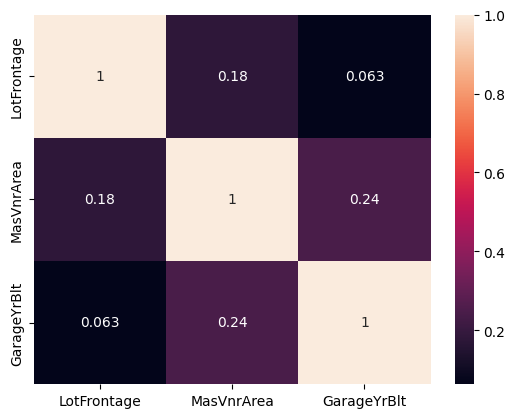

In [ ]:
sns.heatmap(X_train_clean_not_na[numerical_cols_for_corr].corr(), annot = True)

In [ ]:
from sklearn.preprocessing import OneHotEncoder

# Identify categorical columns in X_train_processed
categorical_cols = X_train_processed.select_dtypes(include='object').columns

# Initialize OneHotEncoder
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# Apply OneHotEncoder to categorical columns
X_train_encoded_categorical = ohe.fit_transform(X_train_processed[categorical_cols])

# Create a DataFrame from the one-hot encoded features
X_train_encoded_categorical_df = pd.DataFrame(X_train_encoded_categorical,
                                            columns=ohe.get_feature_names_out(categorical_cols))

# Drop original categorical columns from X_train_processed and concatenate with one-hot encoded features
X_train_final_processed = pd.concat([
    X_train_processed.drop(columns=categorical_cols).reset_index(drop=True),
    X_train_encoded_categorical_df
], axis=1)

display(X_train_final_processed.head())

,LotFrontage,MasVnrArea,GarageYrBlt,Alley_Grvl,Alley_Pave,MasVnrType_BrkCmn,MasVnrType_BrkFace,MasVnrType_Stone,BsmtQual_Ex,BsmtQual_Fa,...,Fence_GdPrv,Fence_GdWo,Fence_MnPrv,Fence_MnWw,Fence_missing,MiscFeature_Gar2,MiscFeature_Othr,MiscFeature_Shed,MiscFeature_TenC,MiscFeature_missing
0,-0.229372,0.514104,1.017598,1.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
1,0.451936,-0.570750,-0.107927,1.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
2,-0.093110,0.325915,0.934226,1.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
3,-0.456474,-0.570750,0.809167,1.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
4,0.633618,1.366489,0.892540,1.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0


In [ ]:
print(f"Shape of X_train_final_processed: {X_train_final_processed.shape}")
display(X_train_final_processed.info())

Shape of X_train_final_processed: (1460, 79)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 79 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   LotFrontage           1460 non-null   float64
 1   MasVnrArea            1460 non-null   float64
 2   GarageYrBlt           1460 non-null   float64
 3   Alley_Grvl            1460 non-null   float64
 4   Alley_Pave            1460 non-null   float64
 5   MasVnrType_BrkCmn     1460 non-null   float64
 6   MasVnrType_BrkFace    1460 non-null   float64
 7   MasVnrType_Stone      1460 non-null   float64
 8   BsmtQual_Ex           1460 non-null   float64
 9   BsmtQual_Fa           1460 non-null   float64
 10  BsmtQual_Gd           1460 non-null   float64
 11  BsmtQual_TA           1460 non-null   float64
 12  BsmtCond_Fa           1460 non-null   float64
 13  BsmtCond_Gd           1460 non-null   float64
 14  BsmtCond_Po           1460 

None

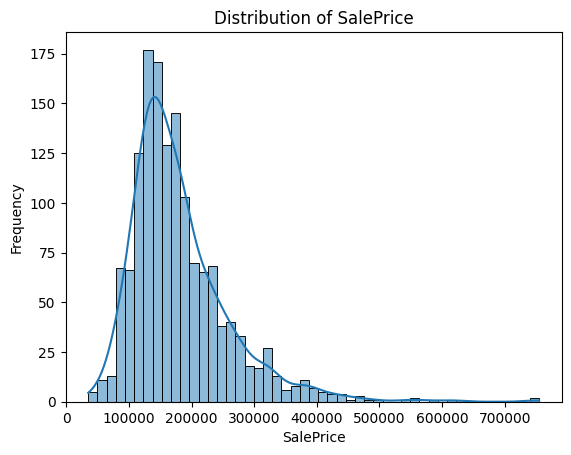

In [ ]:
import matplotlib.pyplot as plt

sns.histplot(y_train, kde=True)
plt.title('Distribution of SalePrice')
plt.xlabel('SalePrice')
plt.ylabel('Frequency')
plt.show()

### Outlier Removal using IQR

I will now remove outliers from the numerical features in `X_train_final_processed` using the Interquartile Range (IQR) method. Outliers are identified as data points that fall below `Q1 - 1.5 * IQR` or above `Q3 + 1.5 * IQR`.

In [ ]:
Q1 = X_train_final_processed.quantile(0.25)
Q3 = X_train_final_processed.quantile(0.75)
IQR = Q3 - Q1

# Define outlier bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Create a boolean mask for identifying outliers
outlier_mask = (
    (X_train_final_processed < lower_bound) | (X_train_final_processed > upper_bound)
).any(axis=1)

# Filter out the outliers from X_train_final_processed and y_train
X_train_no_outliers = X_train_final_processed[~outlier_mask]
y_train_no_outliers = y_train[~outlier_mask]

print(f"Original shape of X_train_final_processed: {X_train_final_processed.shape}")
print(f"Shape of X_train_no_outliers after removing outliers: {X_train_no_outliers.shape}")
print(f"Original shape of y_train: {y_train.shape}")
print(f"Shape of y_train_no_outliers after removing outliers: {y_train_no_outliers.shape}")

display(X_train_no_outliers.head())

Original shape of X_train_final_processed: (1460, 79)
Shape of X_train_no_outliers after removing outliers: (114, 79)
Original shape of y_train: (1460,)
Shape of y_train_no_outliers after removing outliers: (114,)


,LotFrontage,MasVnrArea,GarageYrBlt,Alley_Grvl,Alley_Pave,MasVnrType_BrkCmn,MasVnrType_BrkFace,MasVnrType_Stone,BsmtQual_Ex,BsmtQual_Fa,...,Fence_GdPrv,Fence_GdWo,Fence_MnPrv,Fence_MnWw,Fence_missing,MiscFeature_Gar2,MiscFeature_Othr,MiscFeature_Shed,MiscFeature_TenC,MiscFeature_missing
0,-0.229372,0.514104,1.017598,1.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
18,-0.183951,-0.570750,1.059284,1.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
22,0.224833,0.984576,0.975912,1.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
38,-0.093110,-0.570750,-1.066708,1.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
57,0.860721,-0.570750,1.059284,1.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0


### Visualizing the Distribution of Removed Outliers

Let's visualize the `SalePrice` distribution of the removed outliers and compare it with the original `SalePrice` and the `SalePrice` after outlier removal.

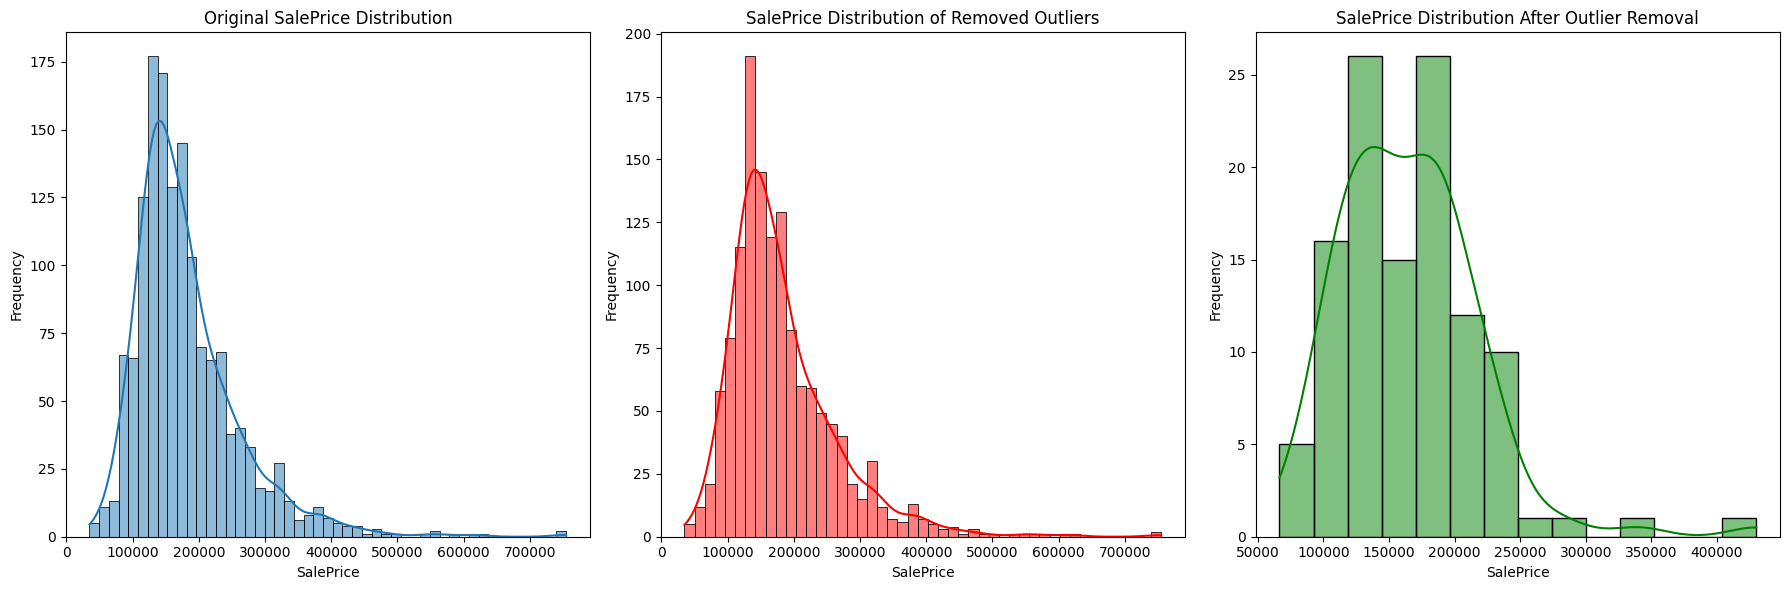

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get the SalePrice for the removed outliers
y_train_outliers = y_train[outlier_mask]

plt.figure(figsize=(18, 6))

# Subplot 1: Original SalePrice Distribution
plt.subplot(1, 3, 1)
sns.histplot(y_train, kde=True)
plt.title('Original SalePrice Distribution')
plt.xlabel('SalePrice')
plt.ylabel('Frequency')

# Subplot 2: SalePrice Distribution of Removed Outliers
plt.subplot(1, 3, 2)
sns.histplot(y_train_outliers, kde=True, color='red')
plt.title('SalePrice Distribution of Removed Outliers')
plt.xlabel('SalePrice')
plt.ylabel('Frequency')

# Subplot 3: SalePrice Distribution After Outlier Removal
plt.subplot(1, 3, 3)
sns.histplot(y_train_no_outliers, kde=True, color='green')
plt.title('SalePrice Distribution After Outlier Removal')
plt.xlabel('SalePrice')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()